### Import packages

In [1]:
import os, subprocess, pickle, warnings, logging, copy
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import healpy as hp

from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
from scipy.stats import norm
from scipy.optimize import curve_fit, root_scalar
from scipy.ndimage import gaussian_filter

# --- Gammapy ---
from gammapy import __version__ as gammapy_version
from gammapy.irf import load_irf_dict_from_file
from gammapy.maps import MapAxis, WcsGeom, Map
from gammapy.modeling.models import PointSpatialModel, PowerLawSpectralModel, ConstantTemporalModel, SkyModel, Models
from gammapy.data import DataStore, Observation, FixedPointingInfo, PointingMode
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, RingBackgroundMaker
from gammapy.datasets import Dataset, Datasets, MapDataset, MapDatasetOnOff
from gammapy.estimators import ExcessMapEstimator, TSMapEstimator
from gammapy.stats.fit_statistics import cash
from gammapy.estimators.map.excess import convolved_map_dataset_counts_statistics, _get_convolved_maps
observing_location = EarthLocation.of_site("Roque de los Muchachos")

# --- Configurations ---
warnings.filterwarnings("ignore", category=RuntimeWarning, append=True)
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", message=".*outside valid IRF map range.*")
logging.getLogger("gammapy").setLevel(logging.ERROR)

# --- External & Local Utils ---
import ligo.skymap.plot
from ligo.skymap.io.fits import read_sky_map
import utils

# We create the needed paths
for path in ["./data/", "./data/tmp/", "./data/gw_input/", "./data/results/", "./data/slurm_output/"]:
    os.makedirs(path, exist_ok=True)

from gammapy import __version__ as gammapy_version
from gammapy import __path__ as gammapy_path
print(f"Using Gammapy version: {gammapy_version}\nIn path: {gammapy_path[0]}")

Using Gammapy version: 2.0.1
In path: /fefs/aswg/workspace/juan.jimenez/softs/conda/envs/gammapy-dev/lib/python3.13/site-packages/gammapy


In [2]:
import importlib
importlib.reload(utils)

<module 'utils' from '/fefs/aswg/workspace/juan.jimenez/lstreco/gw-gamma-global-uls/utils.py'>

##### <span style="color:blue">Main parameters</span>
* `source_name` Source name
* `dir_dl3` DL3 directory
* `e_min`, `e_max` and `e_bins`: Maximum, minimum energies and bins per decade
* `obs_id`: The run numbers to be used
* `bkg_type` If you want to use `baccmod` or `pybkgmodel`
* `e_min`, `e_max` and `e_bins`: Maximum, minimum offset, and total bins

In [3]:
source_name = "S240615dg"
source_coord = SkyCoord(ra=7.53, dec=45.81, unit="deg")

dir_dl3 = os.path.join(
    "/fefs/aswg/workspace/juan.jimenez/data/real", "mono", source_name, "v0.11.4", 
    "GammaDiffuse", "prod_standard", "DL3", "gh_dyn70"
)
obs_ids = [17822, 17823, 17824, 17825]

# Tool used for background computation
bkg_type = "baccmod" # baccmod or pybkgmodel

# Binning: energy and offset
e_min, e_max, e_bins = 0.15 * u.TeV, 0.6 * u.TeV, 4.5
o_min, o_max, o_bins = 0 * u.deg, 2.5 * u.deg, 5 # Offset binning
correlation_radius = 0.05 * u.deg

In [4]:
# source_name = "S240615dg"
# source_coord = SkyCoord(ra=7.53, dec=45.81, unit="deg")

# dir_dl3 = os.path.join(
#     "/fefs/aswg/workspace/juan.jimenez/data/real", "stereo", source_name, "v0.6.1", 
#     "GammaDiffuse", "prod_standard", "DL3", "gh_dyn90"
# )

# obs_ids = [17821, 17822, 17823, 17824, 17825]

# # Tool used for background computation
# bkg_type = "pybkgmodel" # baccmod or pybkgmodel

# # Binning: energy and offset
# e_min, e_max, e_bins = 0.6 * u.TeV, 20 * u.TeV, 4.5
# o_min, o_max, o_bins = 0 * u.deg, 2.5 * u.deg, 8 # Offset binning
# correlation_radius = 0.1 * u.deg

Other secundary parameters

In [5]:
USE_DIRAC_DELTA = True
USE_ITERATIVE_ULS = True
delta_coord = SkyCoord(ra=7.53, dec=45.81, unit="deg")

# Confidence level for SkyMap results
confidence_level = 0.95

n_sim_flux = 500

# --- Binning --- #
size_fov = 2.5 * u.deg

# For the ring-wobble method geometry used
ring_r_in, ring_width = 0.3 * u.deg, 0.2 * u.deg

resolution_hp_to_grid = 2048 # Resolution of the HEALPix map to be used
threshold_percent_gw = np.flip(np.sort([0.95, 0.5])) # % of probabilities contours

# Geometry parameters --- 
geom_width = size_fov.value * 1.43, size_fov.value * 1.43
binsz = 0.05

# True energy geometry (needs to be larger than the reco energy geom)
e_t_min, e_t_max, e_t_bins = 0.05 * u.TeV, 100 * u.TeV, 6

### <span style="color:blue">Reading GW data</span>

In [6]:
%%time
file_ligo = f"./data/gw_input/{source_name}.fits"

# Extracting coordinates from healpy
ra_bins  = np.linspace(-180, 180, resolution_hp_to_grid)
dec_bins = np.linspace(-90, 90, resolution_hp_to_grid)
ra_grid, dec_grid = np.deg2rad(np.meshgrid(ra_bins, dec_bins))

# Reading GW data
data_ligo_hp, meta_ligo_hp = read_sky_map(file_ligo)
if USE_DIRAC_DELTA:
    nside = hp.get_nside(data_ligo_hp)
    data_ligo_hp = utils.make_dirac_delta_hp(delta_coord, nside)
    data_ligo_2d = utils.make_dirac_delta_2d(delta_coord, ra_bins, dec_bins)
else:
    data_ligo_2d = utils.healpix2map(data_ligo_hp, ra_bins, dec_bins)
data_ligo_2d_smooth = gaussian_filter(data_ligo_2d, sigma=2)

# Getting the thresholds for probability containment
if USE_DIRAC_DELTA:
    threshold_maps = None  # skip contours
else:
    threshold_maps = utils.get_hp_map_thresholds(data_ligo_hp, threshold_percent_gw)
    
# Getting the coordinate of hottest spot
hotspot_coord = utils.get_2d_map_hotspot(data_ligo_2d, ra_bins, dec_bins)

CPU times: user 15.8 s, sys: 10.2 s, total: 26 s
Wall time: 26 s


### Defining the geometry (FoV, Energy axis, Spatial Binning)

Energy axis edges:


<Quantity [0.15      , 0.23811016, 0.37797631, 0.6       ] TeV>


Offset axis edges:


<Quantity [0. , 0.5, 1. , 1.5, 2. , 2.5] deg>

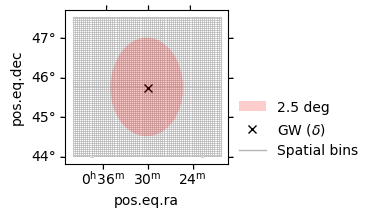

In [7]:
# Defining offset axis
axis_offset = MapAxis.from_bounds(o_min, o_max, nbin=o_bins, name="offset")
# Defining energy axis
axis_energy = MapAxis.from_energy_bounds(
    e_min, e_max, nbin=e_bins, per_decade=True, name="energy"
)
axis_energy_true = MapAxis.from_energy_bounds(
    e_t_min, e_t_max, nbin=e_bins, per_decade=True, name="energy_true"
)
print(f"Energy axis edges:"); display(axis_energy.edges)
print(f"\nOffset axis edges:"); display(axis_offset.edges)

npix = (int(geom_width[0]/binsz), int(geom_width[1]/binsz))
geom = WcsGeom.create(
    skydir=(source_coord.ra.degree, source_coord.dec.degree), 
    npix=npix, binsz=binsz, width=geom_width, frame="icrs", proj="AIR", axes=[axis_energy],
)
geom_image = geom.to_image()

# Extracting coords of geom
geom_centers = geom.get_coord(mode="center")
geom_edges = geom.get_coord(mode="edges")
bin_c_ra, bin_c_dec = geom_centers.lon[0].value, geom_centers.lat[0].value
bin_edges_ra, bin_edges_dec = geom_edges.lon[0].value, geom_edges.lat[0].value
bin_area = geom_image.solid_angle()
coord_array = SkyCoord(bin_c_ra, bin_c_dec, unit=u.deg)
coord_center = coord_array[(coord_array.shape[0])//2,(coord_array.shape[0])//2]

separations_map = coord_array.separation(SkyCoord(*geom.center_coord)).deg

# Plotting geometry summary
utils.summary_geometry(geom, bin_edges_ra, bin_edges_dec, size_fov, data_ligo_2d, threshold_maps)

### <span style="color:blue">Converting the GW information into the WCS geometry</span>

Geometry covers 100.00% of the GW


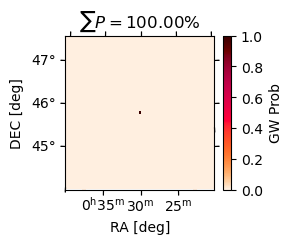

CPU times: user 8.93 s, sys: 5.77 s, total: 14.7 s
Wall time: 14.7 s


In [8]:
%%time
pix_indices, nside = np.arange(len(data_ligo_hp)), hp.npix2nside(len(data_ligo_hp))
dec_hp, ra_hp = utils.IndexToDeclRa(pix_indices, nside)
hp_area = hp.nside2pixarea(nside)

if USE_DIRAC_DELTA:
    prob_gw_integrated, num_hp_pixels = utils.integrate_dirac_delta_on_wcs(
        data_ligo_hp, dec_hp, ra_hp, bin_edges_ra, bin_edges_dec)
else:
    prob_gw_integrated, num_hp_pixels = utils.integrate_hp_on_wcs(
        data_ligo_hp, dec_hp, ra_hp, hp_area, bin_edges_ra, bin_edges_dec, bin_area)

norm_factor_gammapy_region = np.sum(prob_gw_integrated.ravel())
print(f"Geometry covers {norm_factor_gammapy_region * 100:.2f}% of the GW")
prob_gw = np.clip(prob_gw_integrated, a_min=1e-20, a_max=np.inf)
log_gw  = 2 * np.log(prob_gw)

masks_thresholds = []
if threshold_maps is not None:
    for level in threshold_maps:
        cs = plt.contour(np.rad2deg(ra_grid), np.rad2deg(dec_grid), np.flip(data_ligo_2d, axis=1), levels=[level])
        paths = cs.get_paths()
        plt.close()
        ra_wrapped = -((bin_c_ra + 180) % 360) + 180
        mask = [[any(p.contains_point((ra_wrapped[i,j], bin_c_dec[i,j])) for p in paths)
                 for j in range(bin_c_ra.shape[1])] for i in range(bin_c_ra.shape[0])]
        masks_thresholds.append(np.array(mask))
else:
    masks_thresholds = [prob_gw_integrated == 1.0]

mask_threshold_95 = masks_thresholds[0]
utils.summary_gw_map(geom, bin_edges_ra, bin_edges_dec, prob_gw)

### Reading the DL3 data and adding BKG hdu

In [9]:
data_store_real = DataStore.from_dir(dir_dl3)
print(f"Obs IDs in directory: {data_store_real.obs_ids}\n")

obs_collection_real = data_store_real.get_observations(
    obs_id = obs_ids, required_irf = ["aeff", "edisp", "psf"] 
)

# Reading background IRF information and adding it to the information
data_store_real.hdu_table.remove_rows(data_store_real.hdu_table["HDU_TYPE"]=="bkg") # Removing just in case cell is run 2 times
for obs_id in obs_ids:
    data_store_real = utils.add_bkg(data_store_real, obs_id, dir_dl3, dim_bkg=3, bkg_type=bkg_type)

data_store_real.hdu_table = data_store_real.hdu_table.copy() # Copy the table to update the data
obs_collection_real = data_store_real.get_observations(
    obs_id=obs_ids, required_irf=["aeff", "edisp", "psf"]
)

obs_table = data_store_real.obs_table[np.isin(data_store_real.obs_table["OBS_ID"], obs_ids)]
hdu_table = data_store_real.hdu_table[np.isin(data_store_real.hdu_table["OBS_ID"], obs_ids)]
print(f"Total livetime : {obs_table["LIVETIME"].to(u.min).sum():.2f}\n")
display(obs_table); display(hdu_table)

Obs IDs in directory: [17820 17821 17822 17823 17824 17825]

Total livetime : 76.13 min



OBS_ID,DATE-OBS,TIME-OBS,DATE-END,TIME-END,RA_PNT,DEC_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,RA_OBJ,DEC_OBJ,TSTART,TSTOP,ONTIME,TELAPSE,LIVETIME,DEADC,OBJECT,OBS_MODE,N_TELS,TELLIST,INSTRUME
,,,,,deg,deg,deg,deg,deg,deg,deg,s,s,s,s,s,,,,,,
int64,bytes10,bytes12,bytes10,bytes12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes9,bytes8,int64,bytes5,bytes5
17822,2024-06-16,03:17:59.537,2024-06-16,03:38:01.082,7.493825891282605,46.212115403792225,55.2632696091618,34.7367303908382,51.40397554281095,7.69,45.67,180155879.53714827,180157081.08229947,1195.7269394397736,1201.5451512038708,1134.9183227454248,0.9491450642377941,S240615dg,POINTING,1,LST-1,LST-1
17823,2024-06-16,03:38:23.488,2024-06-16,03:58:23.832,7.4971551933661935,45.41107040873675,51.83976977704598,38.16023022295402,52.81797753468018,7.69,45.67,180157103.4876945,180158303.83224896,1200.323659658432,1200.3445544540882,1143.2194559120799,0.9524259950332047,S240615dg,POINTING,1,LST-1,LST-1
17824,2024-06-16,03:58:43.650,2024-06-16,04:18:48.660,8.073213229364793,45.80868850408393,48.72668281576751,41.27331718423249,52.47482929072374,7.69,45.67,180158323.649524,180159528.65955472,1205.0278496742249,1205.0100307166576,1148.9473744213078,0.9534612621043752,S240615dg,POINTING,1,LST-1,LST-1
17825,2024-06-16,04:19:11.787,2024-06-16,04:39:00.371,6.92848138815696,45.80766648350139,44.41920051067039,45.58079948932961,52.31826504432189,7.69,45.67,180159551.78711033,180160740.37080288,1188.5843360424042,1188.5836925506592,1140.4502493735395,0.9595030110954218,S240615dg,POINTING,1,LST-1,LST-1


OBS_ID,HDU_TYPE,HDU_CLASS,FILE_DIR,FILE_NAME,HDU_NAME,SIZE
int64,bytes8,bytes9,bytes1,bytes25,bytes17,int64
17822,events,events,.,dl3_LST-1.Run17822.fits,EVENTS,13466880
17822,gti,gti,.,dl3_LST-1.Run17822.fits,GTI,13466880
17822,pointing,pointing,.,dl3_LST-1.Run17822.fits,POINTING,13466880
17822,aeff,aeff_2d,.,dl3_LST-1.Run17822.fits,EFFECTIVE AREA,13466880
17822,edisp,edisp_2d,.,dl3_LST-1.Run17822.fits,ENERGY DISPERSION,13466880
17822,psf,psf_table,.,dl3_LST-1.Run17822.fits,PSF,13466880
17823,events,events,.,dl3_LST-1.Run17823.fits,EVENTS,20796480
17823,gti,gti,.,dl3_LST-1.Run17823.fits,GTI,20796480
17823,pointing,pointing,.,dl3_LST-1.Run17823.fits,POINTING,20796480


#### Showing summaries for all the data + IRFs inside the DL3

EVENTS SUMMARY:


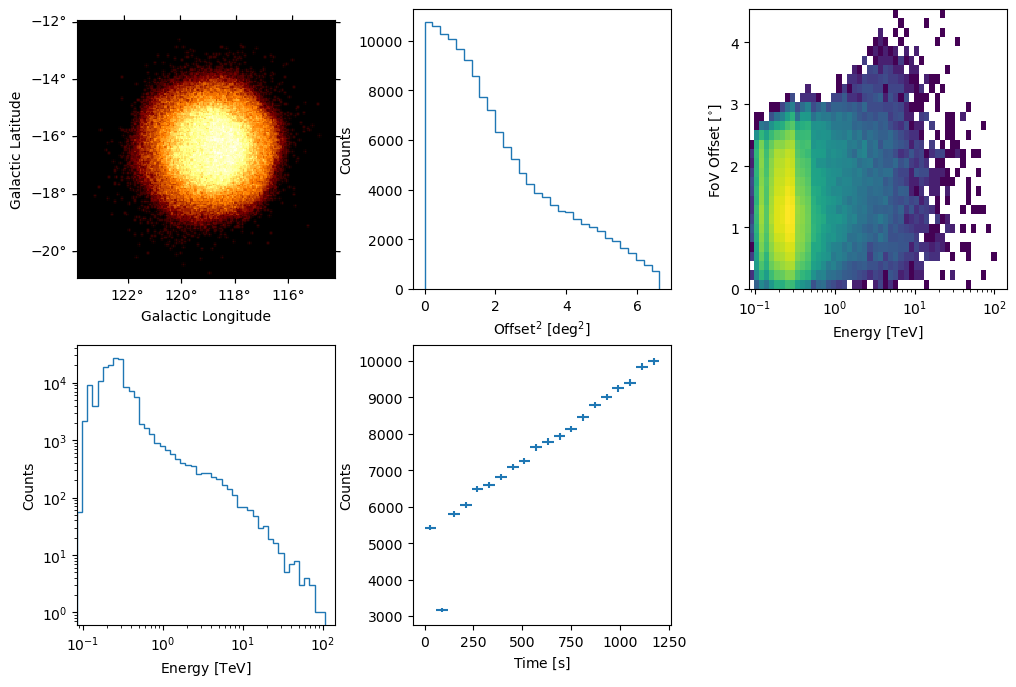

EFFECTIVE AREA SUMMARY:


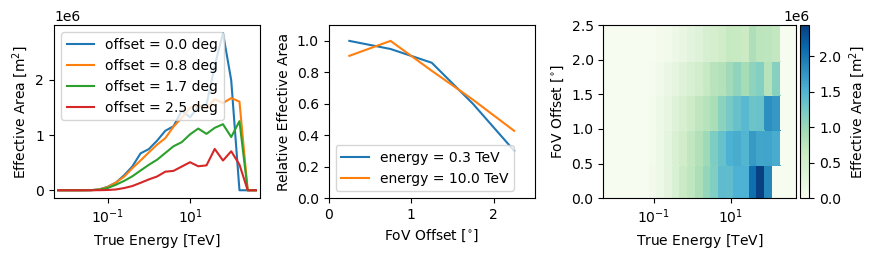

ENERGY DISPERSION SUMMARY:


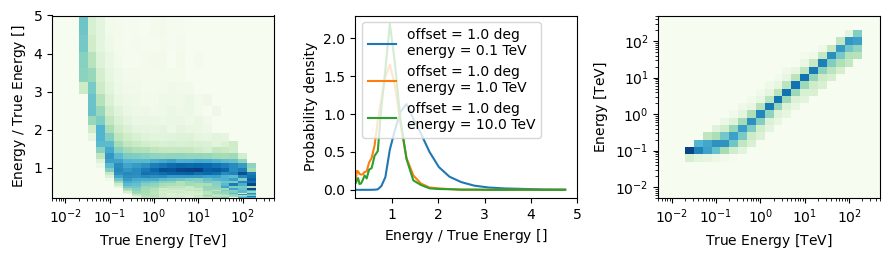

PSF SUMMARY:


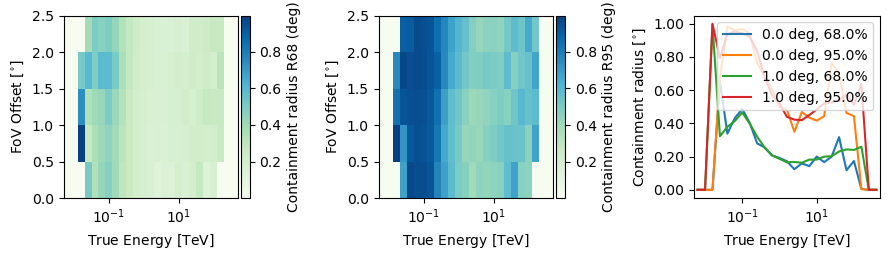

BACKGROUND SUMMARY:


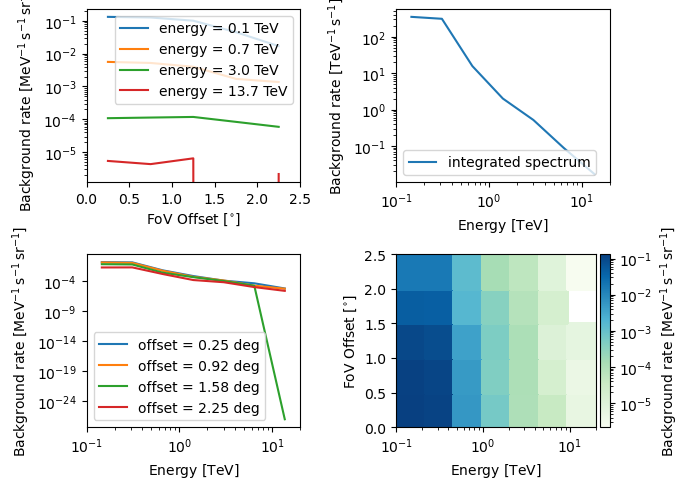

In [10]:
obs = obs_collection_real[0]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    print("EVENTS SUMMARY:"); obs.events.peek(); plt.show()
    print("EFFECTIVE AREA SUMMARY:"); obs.aeff.peek(figsize=(9, 2.7)); plt.show()
    print("ENERGY DISPERSION SUMMARY:"); obs.edisp.peek(figsize=(9, 2.7)); plt.show()
    print("PSF SUMMARY:"); obs.psf.peek(figsize=(9, 2.7)); plt.show()
    print("BACKGROUND SUMMARY:"); obs.bkg.peek(figsize=(7, 5)); plt.show()

#### We run the pipeline for the real data to compare

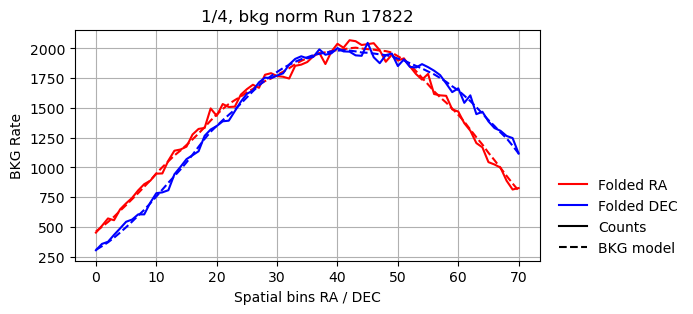

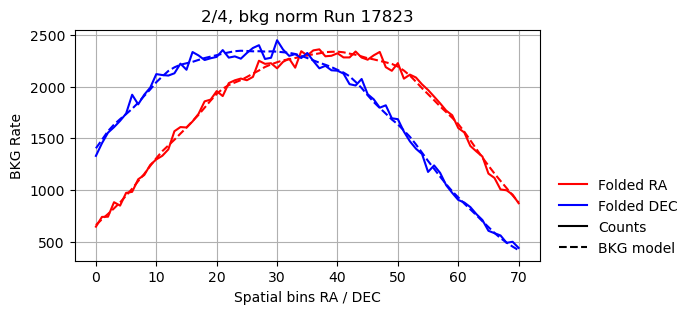

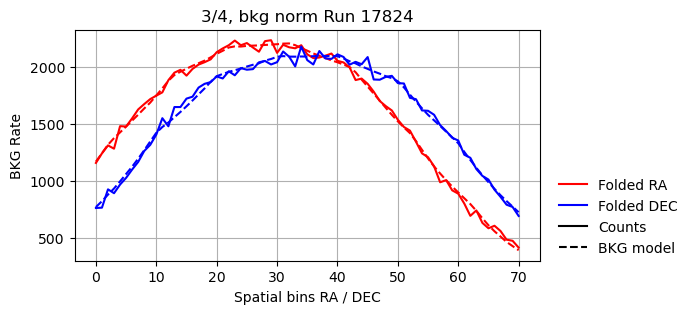

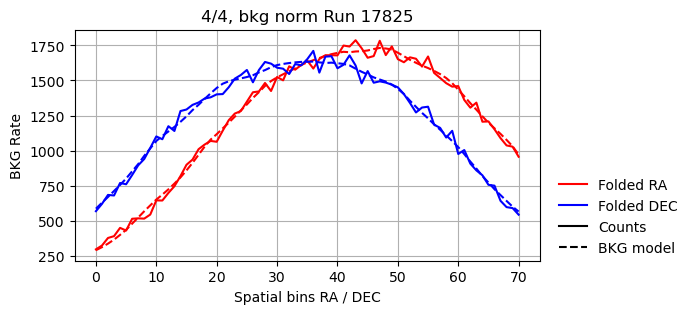

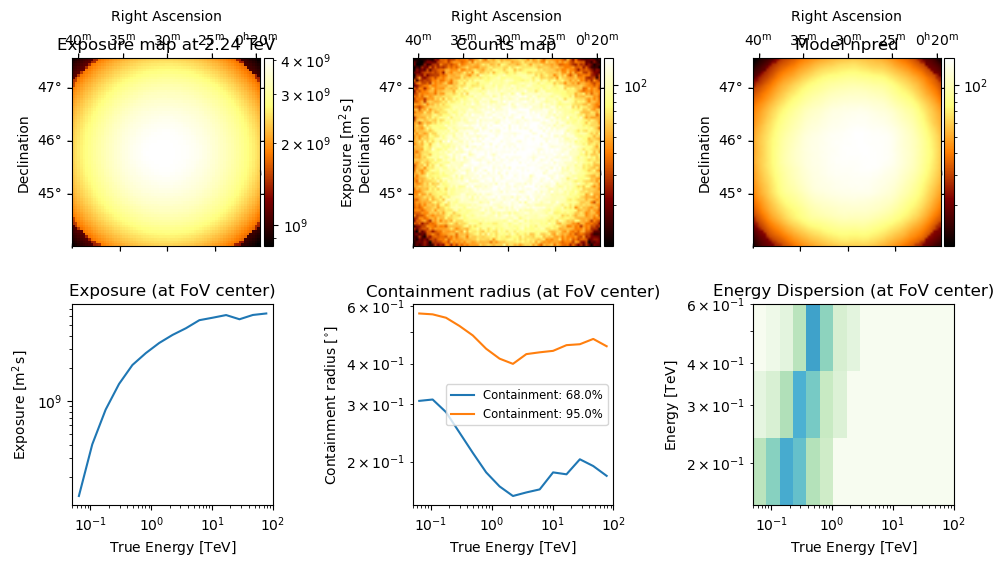

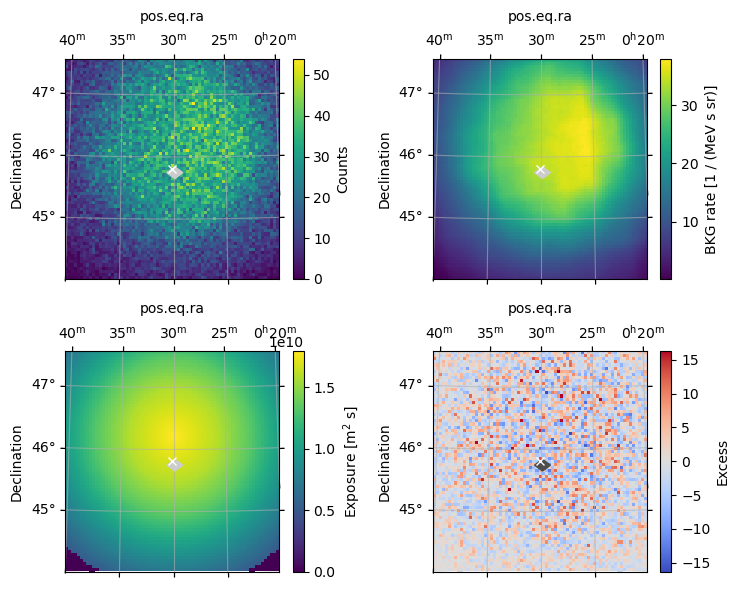

In [11]:
maker = MapDatasetMaker(selection=["counts", "background", "psf", "edisp", "exposure"])
maker_safe_mask = SafeMaskMaker(methods=["aeff-default", "offset-max"], offset_max=size_fov)
maker_ring = RingBackgroundMaker(r_in=ring_r_in, width=ring_width, exclusion_mask=None)

dataset_empty = MapDataset.create(geom, energy_axis_true=axis_energy_true)
dataset_stacked_real = MapDataset.create(geom, energy_axis_true=axis_energy_true) # dataset_stacked_real = MapDatasetOnOff.create(geom)

dataset_real, bkg_models = [], []
for i, obs in enumerate(obs_collection_real[:]):
    dataset = maker.run(dataset_empty.copy(), obs)
    dataset = maker_safe_mask.run(dataset, obs)
    dataset_on_off = maker_ring.run(dataset)
    
    dataset_real.append(dataset_on_off)
    dataset_stacked_real.stack(dataset_on_off)
    
    utils.summary_folded_counts(dataset_on_off, bin_c_ra, obs, i, len(obs_collection_real))
    
    # Storing the normalized bkg model
    bkg_models.append(dataset_on_off.background.copy())

datasets_all_real = Datasets(dataset_real)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    dataset_stacked_real.peek(figsize=(10, 6))
utils.summary_maps(
    dataset_real[0], geom, bin_edges_ra, bin_edges_dec, 
    data_ligo_2d, threshold_maps, source_coord, source_name
)

### Defining the estimators needed
* `ExcessMapEstimator`: We use it for TS computation as is faster, and less complex. It uses a TopHat smearing for convolving the reco maps.
* `TSMapEstimator`: We use it for Flux computation. It takes more time but uses the full PSF for convolution of maps.

In [12]:
energy_edges = [axis_energy.edges[0], axis_energy.edges[-1]]
    
spatial_model = PointSpatialModel(lon_0=source_coord.ra, lat_0=source_coord.dec)
spectral_model = PowerLawSpectralModel(index=2)
model = SkyModel(spatial_model=spatial_model, spectral_model=spectral_model)

excess_estimator = ExcessMapEstimator(
    correlation_radius = correlation_radius,
    correlate_off = True,
    spectral_model = spectral_model,
    energy_edges = energy_edges,
    sum_over_energy_groups = True,
    selection_optional = ["ul"] # "all",
)

model = SkyModel(
    spectral_model = PowerLawSpectralModel(),
    spatial_model = PointSpatialModel(lon_0=source_coord.ra, lat_0=source_coord.dec),
)

ts_estimator = TSMapEstimator(
    model = model,
    energy_edges = energy_edges,
    sum_over_energy_groups = True,
    selection_optional = ["ul"] # "all",
)

# Changing the UL sigmas ot the one sided C.L.
ts_estimator.n_sigma_ul = norm.ppf(confidence_level)
excess_estimator.n_sigma_ul = norm.ppf(confidence_level)

### Computing $ \Lambda$ for the real data

Instead of computing the UL (just for following same procedure in the simulations) we first compute the "stats", that is much faster. This include TS and the related quantities.

We compute our main parameter $\Lambda$, that is defined as the maximum TS' in the 95% region.

In [13]:
stats_real = convolved_map_dataset_counts_statistics(
    convolved_maps = _get_convolved_maps(
        dataset = dataset_stacked_real, 
        kernel = excess_estimator.estimate_kernel(dataset_stacked_real), 
        mask = excess_estimator.estimate_mask_default(dataset_stacked_real), 
        correlate_off = excess_estimator.correlate_off
    ),
    stat_type = "cash" # "wstat" or "cash", cash works with OnOffMapDataset
)

In [14]:
# Computing stats values ---
lik_alt  = cash(stats_real.n_on.sum(axis=0), stats_real.n_on.sum(axis=0))
lik_null = cash(stats_real.n_on.sum(axis=0), stats_real.mu_bkg.sum(axis=0))
ts_sign  = np.where((stats_real.n_on.sum(axis=0) - stats_real.mu_bkg.sum(axis=0)) >= 0.0, +1.0, -1.0)
ts  = np.where((lik_null - lik_alt) < 0.0, 0.0, (lik_null - lik_alt))
ts  = ts * ts_sign
ts2 = ts + 2 * np.log(prob_gw)

# Checking only in 95% area only ---
ts2_masked   = np.where(mask_threshold_95, ts2, np.nan)
ts2_argmax   = np.unravel_index(np.nanargmax(ts2_masked), ts2_masked.shape)

lambda_real  = np.nanmax(ts2_masked)
lambda_coord_real = SkyCoord(ra=bin_c_ra[ts2_argmax], dec=bin_c_dec[ts2_argmax], unit=u.deg, frame="icrs")

Plotting all the stats maps obtained.

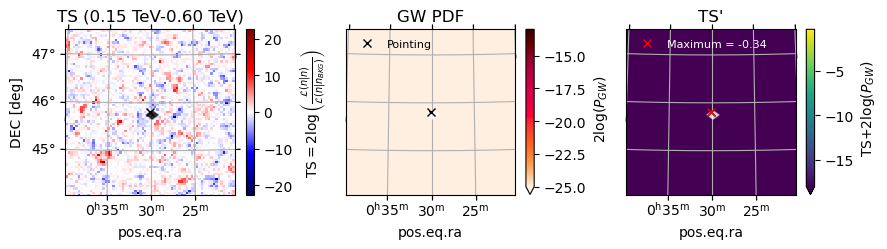

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 2.6), subplot_kw={"projection": geom.wcs})

tsmax = np.max(np.abs([np.nanmax(ts), np.nanmin(ts)]))
a1 = ax1.pcolormesh(
    bin_c_ra, bin_c_dec, ts, shading="nearest", transform=ax1.get_transform("icrs"), cmap="seismic", vmin=-tsmax, vmax=tsmax
)
a2 = ax2.pcolormesh(
    bin_c_ra, bin_c_dec, log_gw, shading="nearest", transform=ax2.get_transform("icrs"), cmap="cylon", vmin=-25, vmax=-13,
)
a3 = ax3.pcolormesh(
    bin_c_ra, bin_c_dec, ts2, shading="nearest", transform=ax3.get_transform("icrs"), cmap="viridis", vmin=-18
)
fig.colorbar(a1, ax=ax1, label="TS$=2\\log\\left(\\frac{\\mathcal{L}(n|n)}{\\mathcal{L}(n|n_{BKG})}\\right)$")
fig.colorbar(a2, ax=ax2, label=r"$2\log(P_{GW})$", extend="min")
fig.colorbar(a3, ax=ax3, label=r"TS$+2\log(P_{GW})$", extend="min")

for ax in [ax1, ax2, ax3]:
    lims = ax.get_xlim(), ax.get_ylim()
    ax.contour(
        data_ligo_2d, levels=threshold_maps, transform=ax.get_transform("icrs"), 
        origin="lower", linewidths=1, alpha=0.5,
        extent=[-180, 180, -90, 90], colors="w" if ax != ax1 else "k", 
    ); delta = 1.0
    ax.set_xlim(lims[0][0]+delta, lims[0][1]-delta); ax.set_ylim(lims[1][0]+delta, lims[1][1]-delta)

    ax.plot(source_coord.ra.deg, source_coord.dec.deg, "x", transform=ax.get_transform("icrs"),
            label="Pointing" if ax == ax2 else None, color="k", ls="")
    ax.set_xlabel("RA [deg]"); ax.grid()
    ax.coords[0].set_axislabel_position("b"); ax.coords[0].set_ticklabel_position("b")

ax3.plot(lambda_coord_real.ra.deg, lambda_coord_real.dec.deg, "x", color="r", ls="",
         transform=ax.get_transform("icrs"),label=f"Maximum = {lambda_real:.2f}")
    
for dec in (ax2.coords[1], ax3.coords[1]):
    dec.set_ticks_visible(False)
    dec.set_ticklabel_visible(False)

ax1.set(ylabel="DEC [deg]", title=f"TS ({axis_energy.edges[0]:.2f}-{axis_energy.edges[-1]:.2f})")
ax2.set_title("GW PDF"); ax3.set_title("TS'"); ax2.legend(frameon=False, loc=2, fontsize=8)
l3 = ax3.legend(frameon=False, loc=2, fontsize=8); [text.set_color("w") for text in l3.get_texts()]
plt.tight_layout()

plt.show()

### Getting IRFs, pointing, and timing information from real data
Main goal is taking the `Datasets()` object of real data, and extract all the information:
* IRFs
* Livetime
* Starting time
* Pointings 

Then we have this empty object that we can use to do our simulations repeatedly.

In [16]:
# Getting the IRFs for each observation
obs_irfs, obs_time_ref, obs_pointing, obs_livetime = [], [], [], []
for i, obs_id in enumerate(obs_ids):
    hdu_tab = data_store_real.hdu_table[data_store_real.hdu_table["OBS_ID"] == obs_id]
    obs_tab = data_store_real.obs_table[data_store_real.obs_table["OBS_ID"] == obs_id]
    
    path_dl3 = os.path.join(dir_dl3, hdu_tab[hdu_tab["HDU_NAME"] == "EVENTS"]["FILE_NAME"][0])
    path_bkg = os.path.join(dir_dl3, hdu_tab[hdu_tab["HDU_NAME"] == "BACKGROUND"]["FILE_NAME"][0])
    
    _irfs_ = load_irf_dict_from_file(path_dl3)
    _irf_bkg_ = load_irf_dict_from_file(path_bkg)
    _irfs_.update(_irf_bkg_)

    obs_irfs.append(_irfs_)
    obs_time_ref.append(Time(f"{obs_tab['DATE-OBS'][0]} {obs_tab['TIME-OBS'][0]}", scale="utc"))
    obs_pointing.append(SkyCoord(ra=obs_tab["RA_PNT"][0], dec=obs_tab["DEC_PNT"][0], unit=u.deg, frame="icrs"))
    obs_livetime.append(np.sum(obs_tab["LIVETIME"]))
    print(f"\nRun {obs_id}\n - IRFs: {list(_irfs_.keys())}\n - Livetime {obs_livetime[-1]/60:.2f} min")
    print(f" - Time Ref {obs_time_ref[-1]}")
    print(f" - Pointing (RA={obs_tab['RA_PNT'][0]:.2f}, DEC={obs_tab['DEC_PNT'][0]:.2f})deg")


Run 17822
 - IRFs: ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime 18.92 min
 - Time Ref 2024-06-16 03:17:59.537
 - Pointing (RA=7.49, DEC=46.21)deg

Run 17823
 - IRFs: ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime 19.05 min
 - Time Ref 2024-06-16 03:38:23.488
 - Pointing (RA=7.50, DEC=45.41)deg

Run 17824
 - IRFs: ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime 19.15 min
 - Time Ref 2024-06-16 03:58:43.650
 - Pointing (RA=8.07, DEC=45.81)deg

Run 17825
 - IRFs: ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime 19.01 min
 - Time Ref 2024-06-16 04:19:11.787
 - Pointing (RA=6.93, DEC=45.81)deg


#### Filling the `Observation` object with the extracted data

In [17]:
observations = [Observation.create(
    obs_id = f"{i}",          
    pointing = FixedPointingInfo(obs_pointing[i]),
    livetime = obs_livetime[i] * u.s, 
    irfs = obs_irfs[i], 
    location = observing_location,
    reference_time = obs_time_ref[i],
) for i in range(len(obs_irfs))]

### We create a empty unique dataset for the observations

Only thing left is set the `model` and then simulate the events `.fake()` later.

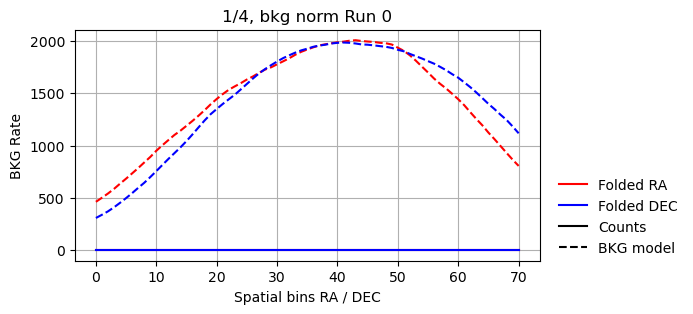

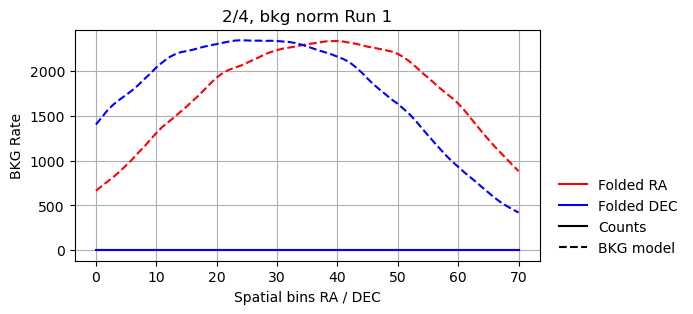

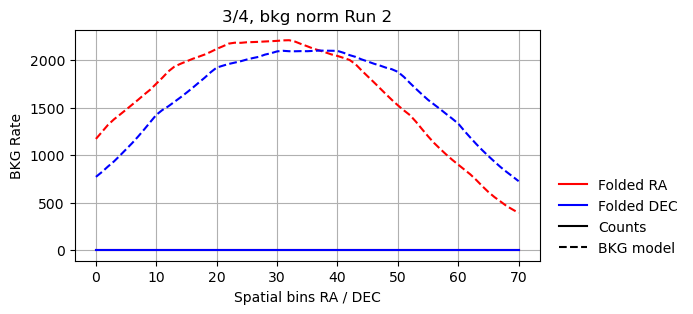

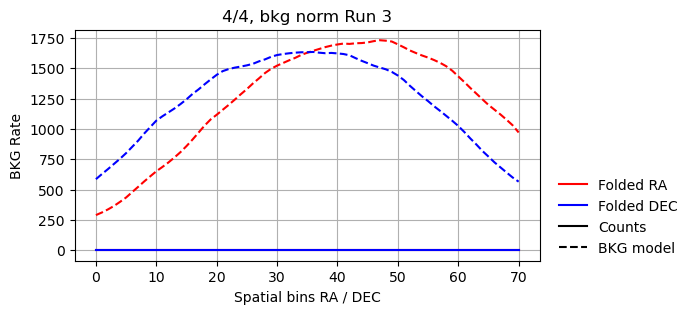

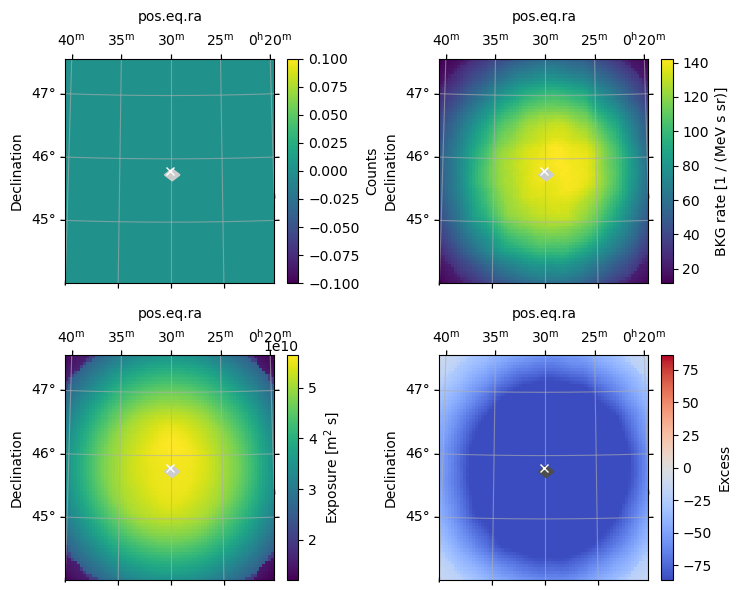

In [18]:
maker = MapDatasetMaker(selection=["background", "psf", "edisp", "exposure"])
maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=size_fov)

dataset_empty = MapDataset.create(geom, energy_axis_true=axis_energy_true)
dataset_stacked_simulated = MapDataset.create(geom, energy_axis_true=axis_energy_true)

dataset_simulated = []
for i, obs in enumerate(observations):
    dataset = maker.run(dataset_empty.copy(), obs)
    dataset = maker_safe_mask.run(dataset, obs)
    dataset.background = bkg_models[i] # Setting the BKG model of real data
    dataset_simulated.append(dataset)
    dataset_stacked_simulated.stack(dataset)
    
    utils.summary_folded_counts(dataset, bin_c_ra, obs, i, len(observations))

dataset_all_simulated = Datasets(dataset_simulated)

# with warnings.catch_warnings():
#     warnings.simplefilter("ignore", category=UserWarning)
#     dataset_stacked_simulated.peek(figsize=(10, 6))
utils.summary_maps(
    dataset_stacked_simulated, geom, bin_edges_ra, bin_edges_dec, data_ligo_2d, threshold_maps, source_coord, source_name
)

### Computing correction factor for `ExcessMapEstimator`

Running estimator for test amplitude 1.0e-08 s-1 cm-2 TeV-1 @ 1 TeV  - 50/50

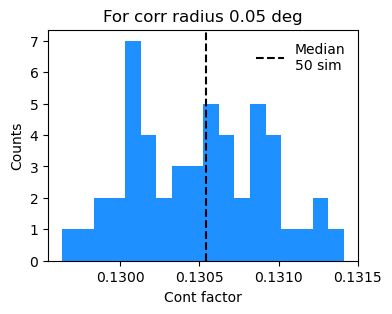

CPU times: user 19.6 s, sys: 590 ms, total: 20.2 s
Wall time: 20.2 s


In [19]:
%%time
nsim_test = 50
test_amplitud = 1e-8 # s-1 cm-2 TeV-1 @ 1 TeV

model_source = Models([
    SkyModel(
        spatial_model = PointSpatialModel.from_position(coord_center),
        spectral_model = PowerLawSpectralModel(
            index=2, amplitude=f"{test_amplitud} cm-2 s-1 TeV-1", reference="1 TeV"
        ),
        temporal_model = ConstantTemporalModel(),
        name="model-simulated-test",
    )
])
true_flux_int = model_source[0].spectral_model.integral(
    excess_estimator.energy_edges[0], excess_estimator.energy_edges[-1]
)
containment_fluxes_test = []
for k in range(nsim_test):
    dataset_test = copy.deepcopy(dataset_stacked_simulated)

    dataset_test.models = model_source
    dataset_test.fake()
    dataset_test.models = None

    str_test = f"Running estimator for test amplitude {test_amplitud:.1e}"
    print(f"{str_test} s-1 cm-2 TeV-1 @ 1 TeV  - {k+1}/{nsim_test}", end="\r")
    result_test = excess_estimator.run(dataset=dataset_test)
    
    central_index = (
        0, len(result_test.flux.data[0][0])//2, len((result_test.flux.data[0]).T[0])//2
    )
    containment_fluxes_test.append(
        result_test.flux.data[central_index]/(u.cm**2)/u.s / true_flux_int
    )
    
containment_factor = np.median(containment_fluxes_test)

fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(containment_fluxes_test, 18, color="dodgerblue")
ax.axvline(containment_factor, color="k", ls="--", label=f"Median\n{nsim_test} sim")
ax.set(xlabel="Cont factor", ylabel="Counts", title=f"For corr radius {correlation_radius}")
ax.legend(frameon=False)
plt.show()

### Computting the Sky-Map ULs for real data
We compute the flux SkyMap using `ExcessEstimator`. The estimator that uses the top-hat kernel, so we need to correct those values for the containment of flux that we computed based on simulations.

Running Excess Map Estimator...


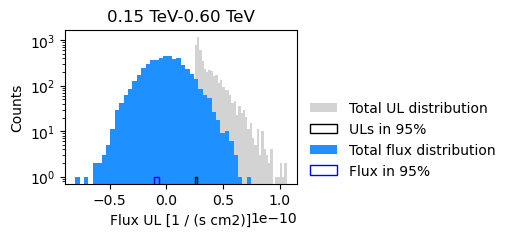

In [20]:
print("Running Excess Map Estimator...")
maps_real = excess_estimator.run(dataset_stacked_real)

# Array fluxes ---
flux_uls = maps_real["flux_ul"].data.ravel() / containment_factor
flux_uls_95 = np.where(mask_threshold_95, maps_real["flux_ul"].data, np.nan).ravel() / containment_factor

fluxs = maps_real["flux"].data.ravel() / containment_factor
fluxs_95 = np.where(mask_threshold_95, maps_real["flux"].data, np.nan).ravel() / containment_factor

fig, ax = plt.subplots(figsize=(3, 2))

h = ax.hist(flux_uls, 40, histtype="stepfilled", color="lightgray", label="Total UL distribution")
ax.hist(flux_uls_95, h[1], histtype="step", color="k", label="ULs in 95%")

h = ax.hist(fluxs, 40, histtype="stepfilled", color="dodgerblue", label="Total flux distribution")
ax.hist(fluxs_95, h[1], histtype="step", color="b", label="Flux in 95%")

ax.set(xlabel="Flux UL [1 / (s cm2)]", ylabel="Counts", yscale="log")
ax.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}"); ax.legend(frameon=False, loc=(1.03, 0))
plt.show()

### Defining the needed input parameters in the simulations

In order to perform the simulations we store the relevant information into a `.pkl` file:
* The ExcessMapEstimator
* The empty dataset to be simulated (all runs contained)
* The GW SkyMap converted into WCS map
* The mask of the Map for the 95% region
* The containment factor for the flux

In [21]:
# From dl3 directory we check if is mono or stereo data
type_obs  = "mono" if "mono" in dir_dl3.lower() else "stereo" if "stereo" in dir_dl3.lower() else "unknown"

kernel = excess_estimator.estimate_kernel(dataset_stacked_simulated)
mask_default = excess_estimator.estimate_mask_default(dataset)

# Storing the empty dataset
path_pkl  = os.path.join("data", "tmp", f"{source_name}_{type_obs}_E_{e_min.value}_{e_max.value}.pkl")
with open(path_pkl, "wb") as file:
    data_pkl = (dataset_stacked_simulated, excess_estimator, ts_estimator, prob_gw, data_ligo_hp, mask_threshold_95, containment_factor, kernel, mask_default)
    pickle.dump(data_pkl, file)
    
# We can also store the real dataset (with real counts)
path_pkl_real  = os.path.join("data", "tmp", f"{source_name}_{type_obs}_E_{e_min.value}_{e_max.value}__real.pkl")
with open(path_pkl_real, "wb") as file:
    data_pkl_real = (dataset_stacked_real, excess_estimator, ts_estimator, prob_gw, data_ligo_hp, mask_threshold_95, containment_factor, kernel, mask_default)
    pickle.dump(data_pkl_real, file)

### <span style="color:red">Extra: storing also the n-on and n-off</span>

In [22]:
# We can also store the real dataset (with real counts)
path_pkl_stats  = os.path.join("data", "tmp", f"{source_name}_{type_obs}_E_{e_min.value}_{e_max.value}_STATS__real.pkl")
with open(path_pkl_stats, "wb") as file:
    pickle.dump(stats_real, file)

# Launching the BKG simulations

In [23]:
%%time
n_sim_bkg = 3500
compute_uls = 0
amplitude_bkg = 0.0
overwrite = True

# First we check if the results file already exists
fname_results_bkg = f"{source_name}_{type_obs}_E_{e_min.value}_{e_max.value}"
fname_results_bkg += f"_N_{n_sim_bkg}_f_{amplitude_bkg}_{'extended' if bool(compute_uls) else ''}.npz"
path_results_bkg = os.path.join("data", "results", fname_results_bkg)

# If data is not already produced
if not os.path.exists(path_results_bkg) or overwrite:
    
    # For the background there is no need of sending jobs as is only one simulation
    # Can take O(5-10min) for a decent amount of statistics to compute the distribution
    utils.perform_n_simulations(
        n_sim = n_sim_bkg,
        amplitude = amplitude_bkg,
        file_input = path_pkl,
        file_output = path_results_bkg,
        compute_uls = compute_uls
    )
else:
    print(f"Data already exists")

# Then we load the data always from the files
print(f"\nLoading for N={n_sim_bkg}...\n")
data_bkg = np.load(path_results_bkg, allow_pickle=True)

# Computing the statistics ---
# Lambda parameter
lambda_bkg = data_bkg["lambda_data"]
lambda_ra_bkg, lambda_dec_bkg = data_bkg["lambda_ra"], data_bkg["lambda_dec"]
# Maximum of TS distribution
tsmax_bkg = data_bkg["tsmax"]
tsmax_ra_bkg, tsmax_dec_bkg = data_bkg["tsmax_ra"], data_bkg["tsmax_dec"]
# Storing th distributions
ts_dist  = data_bkg["ts_dist"]
ts2_dist = data_bkg["ts2_dist"]
# The position of simulated source
f_ra_bkg, f_dec_bkg = data_bkg["f_ra"], data_bkg["f_dec"]

if compute_uls:
    # If we need to compute ULs we also read flux maps
    ulmax_bkg = data_bkg["ulmax"]; ul_dist = data_bkg["ul_dist"]
    ulmax_ra_bkg, ulmax_dec_bkg = data_bkg["ulmax_ra"], data_bkg["ulmax_dec"]
    

Producing 3500 simulations for amplitude 0.0 cm-2 s-1 TeV-1
Setting up everything...

Computing... 3500/3500
Writing file: --> data/results/S240615dg_mono_E_0.15_0.6_N_3500_f_0.0_.npz

Loading for N=3500...

CPU times: user 18min 23s, sys: 58.2 s, total: 19min 21s
Wall time: 19min 21s


Then we can compute some extra parameters of comprobations:
* `p-value` The fraction of simulations above the real value.
* `significance` Converting the p-value to fraction of the normal distribution.
* `lambda median` The median value of BKG distribution, that we will use as reference. 

In [24]:
p_value = len(lambda_bkg[lambda_bkg > lambda_real]) / len(lambda_bkg)
significance = norm.ppf(1 - p_value)
lambda_bkg_m = np.median(lambda_bkg)

# Lambda map
map_lambda_bkg = Map.from_geom(geom=geom_image)
map_lambda_bkg.fill_by_coord({"lon": lambda_ra_bkg * u.deg, "lat": lambda_dec_bkg * u.deg,})
# TS map
map_ts_bkg = Map.from_geom(geom=geom_image)
map_ts_bkg.fill_by_coord({"lon": tsmax_ra_bkg * u.deg, "lat": tsmax_dec_bkg * u.deg,})
# Position of simulated sources maps
map_source_sim = Map.from_geom(geom=geom_image)
map_source_sim.fill_by_coord({"lon": f_ra_bkg * u.deg, "lat": f_dec_bkg * u.deg,})

if compute_uls:
    # Flux ULs
    map_ul_bkg = Map.from_geom(geom=geom_image)
    map_ul_bkg.fill_by_coord({"lon": ulmax_ra_bkg * u.deg, "lat": ulmax_dec_bkg * u.deg,})


nbins_lambda = 100
min_l_bkg, max_l_bkg = lambda_bkg.min(), lambda_bkg.max()
bins_lambda = np.linspace(min_l_bkg, max_l_bkg, nbins_lambda)

#### Crosscheck plot + BKG $\Lambda$ distribution

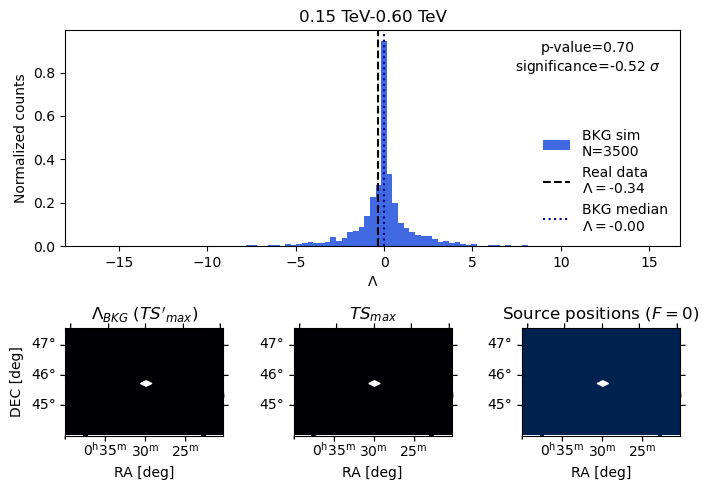

In [25]:
fig = plt.figure(figsize=(7, 5))
gs = GridSpec(2, 3, figure=fig, height_ratios=[2, 1])
axt = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0], projection=geom.wcs)
ax2 = fig.add_subplot(gs[1, 1], projection=geom.wcs)
ax3 = fig.add_subplot(gs[1, 2], projection=geom.wcs)

axt.hist(lambda_bkg, bins_lambda, color="royalblue", 
         density=True, histtype="stepfilled", label=f"BKG sim\nN={len(lambda_bkg)}")
axt.text(
    0.85, 0.87, f"p-value={p_value:.2f}\nsignificance={significance:.2f} $\\sigma$",
    ha="center", va="center", transform=axt.transAxes
)
axt.axvline(lambda_real, color="k", ls="--", label=f"Real data\n$\\Lambda=${lambda_real:.2f}")
axt.axvline(lambda_bkg_m, color="darkblue", ls=":", label=f"BKG median\n$\\Lambda=${lambda_bkg_m:.2f}")

for ax, cmap, mapa, lab in zip(
    [ax1, ax2, ax3], ["magma", "magma", "cividis"],
    [map_lambda_bkg, map_ts_bkg, map_source_sim], 
    [r"$\\Lambda$", r"$TS_{\text{MAX}}$", "Simulated sources"]
):
    pc = ax.pcolormesh(
        bin_edges_ra, bin_edges_dec, mapa.data, cmap=cmap,
        transform=ax.get_transform("icrs")
    )

    lims = ax.get_xlim(), ax.get_ylim()
    ax.contour(
        data_ligo_2d, levels=threshold_maps, transform=ax.get_transform("icrs"), origin="lower",
        extent=[-180, 180, -90, 90], colors="w", linewidths=1,
    )
    ax.set_xlim(lims[0][0], lims[0][1]); ax.set_ylim(lims[1][0], lims[1][1])
    ax.coords[0].set_axislabel_position("b"); ax.coords[0].set_ticklabel_position("b")

axt.legend(frameon=False, loc=4)
axt.set_xlabel("$\\Lambda$"); axt.set_ylabel("Normalized counts")
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("RA [deg]")
ax1.set_ylabel("DEC [deg]"); ax2.set_ylabel(" "); ax3.set_ylabel(" ")
ax1.set_title("$\\Lambda_{BKG}$ ($TS'_{max}$)")
ax2.set_title("$TS_{max}$"); ax3.set_title("Source positions $(F=0)$")
axt.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
fig.tight_layout()

plt.show()

### <span style="color:red">Extra: plotting individual pixel n-on and n-off</span>

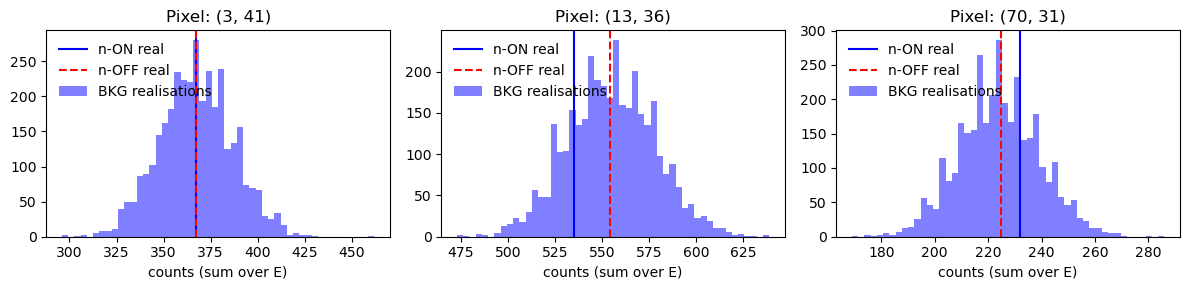

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax in axes:
    random_pixel = (
        np.random.randint(0, bin_edges_ra.shape[0] - 1),
        np.random.randint(0, bin_edges_ra.shape[1] - 1),
    )
    n_on_real = stats_real.n_on.sum(axis=0)[random_pixel]
    n_off_real = stats_real.n_bkg.sum(axis=0)[random_pixel]
    n_on_bkg = [s.n_on.sum(axis=0)[random_pixel] for s in data_bkg["stats"]]

    ax.set_title(f"Pixel: {random_pixel}")
    ax.axvline(n_on_real, color="b", ls="-", label="n-ON real")
    ax.axvline(n_off_real, color="r", ls="--", label="n-OFF real")
    ax.hist(n_on_bkg, 50, color="b", alpha=0.5, label="BKG realisations")
    ax.set_xlabel("counts (sum over E)")
    ax.legend(frameon=False, loc=2)

plt.tight_layout()
plt.show()

# Sending jobs for flux simulations

Producing 500 simulations for amplitude 3.1622776601683794e-12 cm-2 s-1 TeV-1
Setting up everything...

Computing... 500/500
Writing file: --> ./data/tmp/iterative_ul_iter0_3.1623e-12.npz


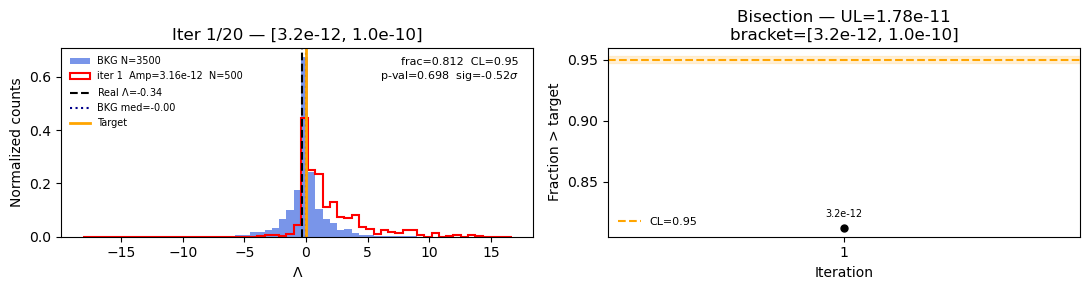

Iter  1: amp=3.1623e-12  N=500  frac=0.812  bracket=[3.16e-12, 1.00e-10]  width=1.500 dex
Producing 500 simulations for amplitude 1.7782794100389227e-11 cm-2 s-1 TeV-1
Setting up everything...

Computing... 500/500
Writing file: --> ./data/tmp/iterative_ul_iter1_1.7783e-11.npz


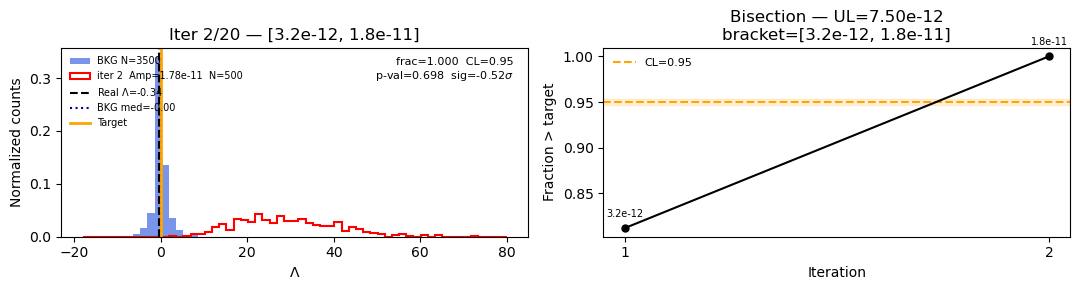

Iter  2: amp=1.7783e-11  N=500  frac=1.000  bracket=[3.16e-12, 1.78e-11]  width=0.750 dex
Producing 500 simulations for amplitude 7.498942093324557e-12 cm-2 s-1 TeV-1
Setting up everything...

Computing... 500/500
Writing file: --> ./data/tmp/iterative_ul_iter2_7.4989e-12.npz


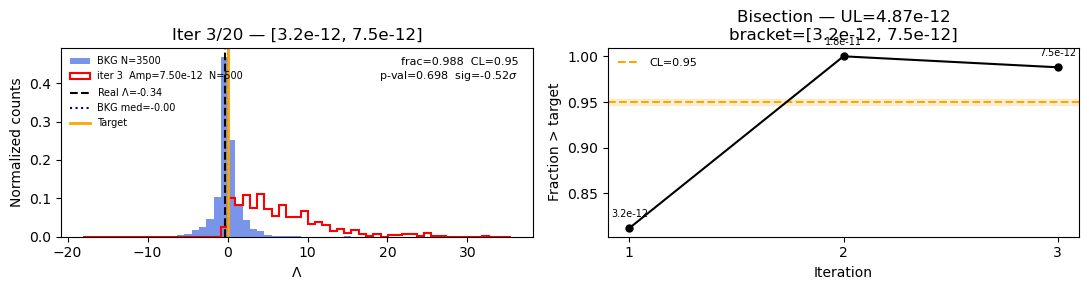

Iter  3: amp=7.4989e-12  N=500  frac=0.988  bracket=[3.16e-12, 7.50e-12]  width=0.375 dex
Producing 500 simulations for amplitude 4.869675251658631e-12 cm-2 s-1 TeV-1
Setting up everything...

Computing... 500/500
Writing file: --> ./data/tmp/iterative_ul_iter3_4.8697e-12.npz


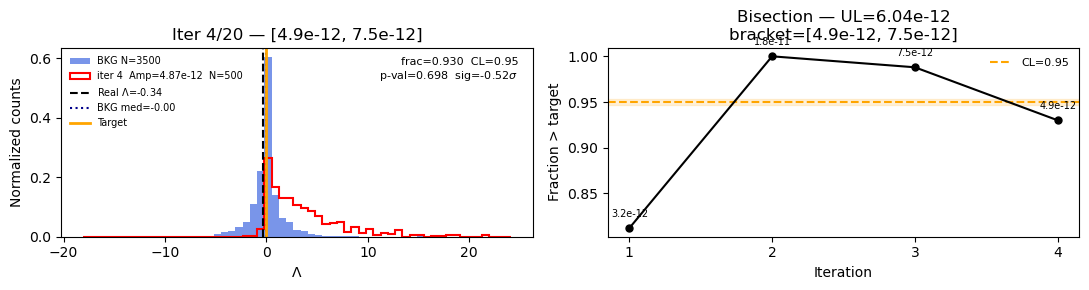

Iter  4: amp=4.8697e-12  N=500  frac=0.930  bracket=[4.87e-12, 7.50e-12]  width=0.187 dex
Producing 500 simulations for amplitude 6.042963902381328e-12 cm-2 s-1 TeV-1
Setting up everything...

Computing... 500/500
Writing file: --> ./data/tmp/iterative_ul_iter4_6.0430e-12.npz


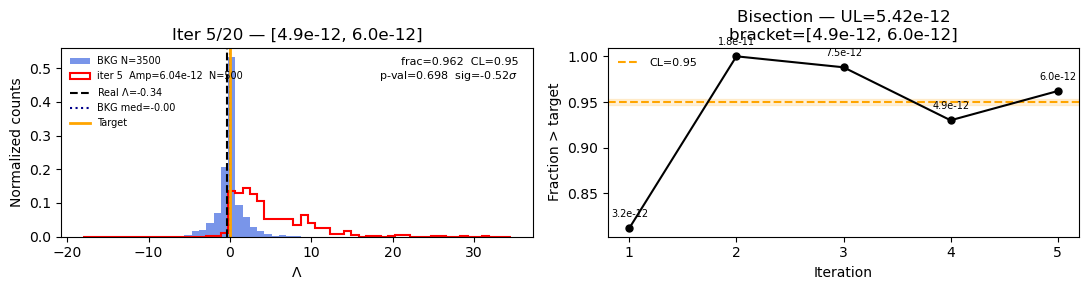

Iter  5: amp=6.0430e-12  N=500  frac=0.962  bracket=[4.87e-12, 6.04e-12]  width=0.094 dex
Producing 500 simulations for amplitude 5.424690937011326e-12 cm-2 s-1 TeV-1
Setting up everything...

Computing... 500/500
Writing file: --> ./data/tmp/iterative_ul_iter5_5.4247e-12.npz


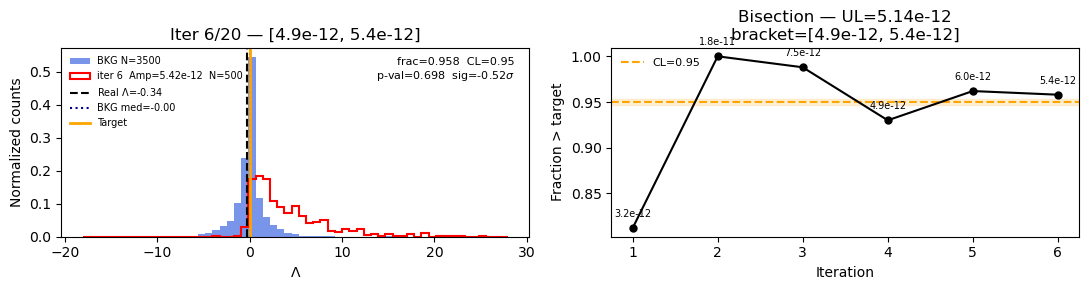

Iter  6: amp=5.4247e-12  N=500  frac=0.958  bracket=[4.87e-12, 5.42e-12]  width=0.047 dex
  Frac converged but bracket still 0.047 dex wide — continuing
Producing 500 simulations for amplitude 5.139696800771513e-12 cm-2 s-1 TeV-1
Setting up everything...

Computing... 500/500
Writing file: --> ./data/tmp/iterative_ul_iter6_5.1397e-12.npz


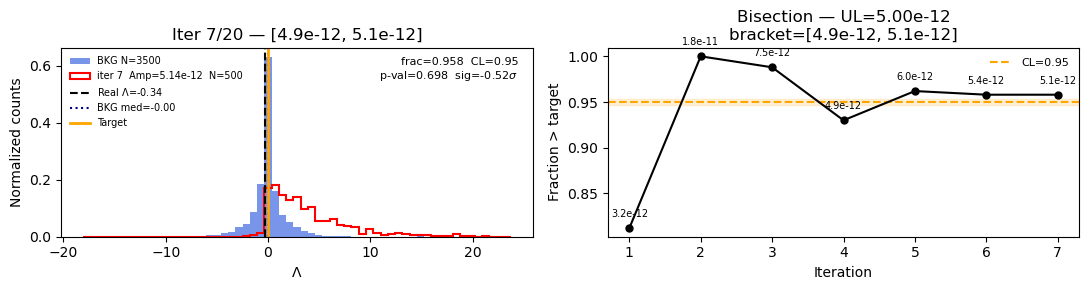

Iter  7: amp=5.1397e-12  N=500  frac=0.958  bracket=[4.87e-12, 5.14e-12]  width=0.023 dex
  Frac converged but bracket still 0.023 dex wide — continuing
Producing 500 simulations for amplitude 5.002864610575233e-12 cm-2 s-1 TeV-1
Setting up everything...

Computing... 500/500
Writing file: --> ./data/tmp/iterative_ul_iter7_5.0029e-12.npz


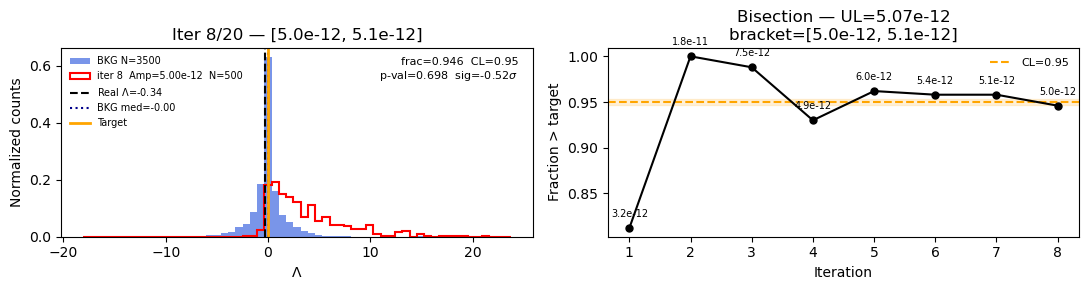

Iter  8: amp=5.0029e-12  N=500  frac=0.946  bracket=[5.00e-12, 5.14e-12]  width=0.012 dex
  Frac converged but bracket still 0.012 dex wide — continuing
Producing 500 simulations for amplitude 5.0708191876329555e-12 cm-2 s-1 TeV-1
Setting up everything...

Computing... 500/500
Writing file: --> ./data/tmp/iterative_ul_iter8_5.0708e-12.npz


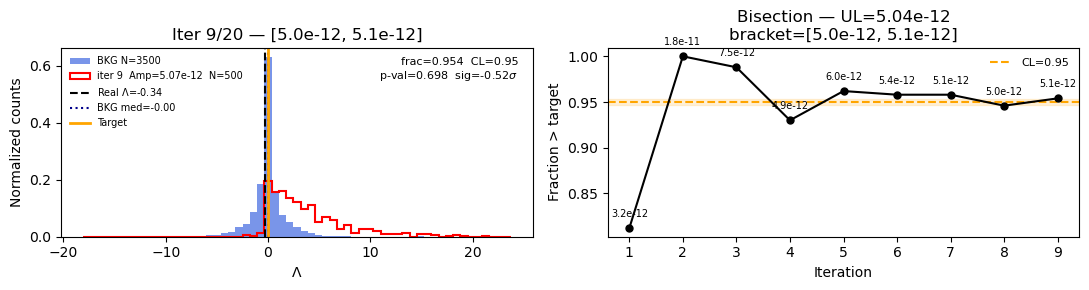

Iter  9: amp=5.0708e-12  N=500  frac=0.954  bracket=[5.00e-12, 5.07e-12]  width=0.006 dex
  Frac converged but bracket still 0.006 dex wide — continuing
Producing 500 simulations for amplitude 5.036727296611836e-12 cm-2 s-1 TeV-1
Setting up everything...

Computing... 500/500
Writing file: --> ./data/tmp/iterative_ul_iter9_5.0367e-12.npz


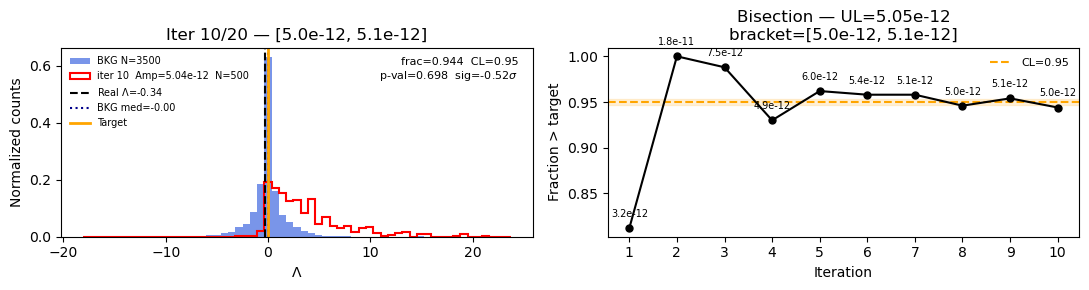

Iter 10: amp=5.0367e-12  N=500  frac=0.944  bracket=[5.04e-12, 5.07e-12]  width=0.003 dex
Converged in 10 iterations — bracket 0.0029 dex < 0.003 dex, |frac - cl| = 0.0060 < 0.01

  UL amplitude : 5.0537e-12 TeV-1 s-1 cm-2
  UL flux      : 2.5269e-11 1 / (s cm2)
  UL diff flux : 1.1225e-11 erg / (s cm2)
  Final bracket: [5.04e-12, 5.07e-12]
  Iterations   : 10
  Total sims   : 5000
  Unique amps  : 10
Saved iterative UL cache → data/tmp/S240615dg_mono_E_0.15_0.6_iterative_nsim500_prec0.05_lo1e-13_hi1e-10.pkl


In [27]:
overwrite = True

if not USE_ITERATIVE_ULS:
    amplitudes    = np.logspace(-13, -10, 150)
    compute_uls_f = 0
    for amplitude in amplitudes:
        fname_results_f  = f"{source_name}_{type_obs}_E_{e_min.value}_{e_max.value}"
        fname_results_f += f"_N_{n_sim_flux}_f_{amplitude}_{'extended' if bool(compute_uls_f) else ''}.npz"
        path_results_f   = os.path.join("data", "results", fname_results_f)
        if os.path.exists(path_results_f):
            print(f"Flux Amplitude: {amplitude:.2e} - Results already exist")
            if not overwrite: continue
            print("Overwriting...")
        _command_     = f"python utils.py {n_sim_flux} {amplitude} {path_pkl} {path_results_f} {compute_uls_f}"
        str_output    = f"-o ./data/slurm_output/job_simulate_{type_obs}_F{amplitude:.4e}_N{n_sim_flux}.out"
        slurm_command = f"sbatch -p short --mem=20000 -J simulate_source {str_output} --wrap='{_command_}'"
        subprocess.run(slurm_command, shell=True, check=True)
else:
    # Cache path encodes all parameters that affect the result
    iterative_cache_file = os.path.join(
        "data", "tmp",
        f"{source_name}_{type_obs}_E_{e_min.value}_{e_max.value}"
        f"_iterative_nsim{n_sim_flux}_prec{0.05}_lo{1e-13:.0e}_hi{1e-10:.0e}.pkl"
    )

    if os.path.exists(iterative_cache_file) and not overwrite:
        print(f"Loading iterative UL cache...\n")
        with open(iterative_cache_file, "rb") as f:
            amp_ul, flux_ul, flux_diff_ul, hist_amp, hist_frac, lambda_cache = pickle.load(f)
    else:
        amp_ul, flux_ul, flux_diff_ul, hist_amp, hist_frac, lambda_cache = utils.run_iterative_ul(
            path_pkl     = path_pkl,
            lambda_real  = lambda_real,
            lambda_bkg   = lambda_bkg,
            lambda_bkg_m = lambda_bkg_m,
            significance = significance,
            p_value      = p_value,
            energy_edges = energy_edges,
            cl           = confidence_level,
            n_sim        = n_sim_flux,
            precision    = 0.003,
            amp_lo       = 1e-13,
            amp_hi       = 1e-10,
            max_iter     = 20,
        )
        with open(iterative_cache_file, "wb") as f:
            pickle.dump((amp_ul, flux_ul, flux_diff_ul, hist_amp, hist_frac, lambda_cache), f)
        print(f"Saved iterative UL cache → {iterative_cache_file}")

    amplitudes = np.array([float(k) for k in lambda_cache.keys()])
    lambda_f   = [lambda_cache[k] for k in lambda_cache.keys()]

In [28]:
!squeue -u juan.jimenez

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON) 


### Reading the result `.npz` files

In [29]:
%%time
cache_file = os.path.join(
    "data", "tmp", f"{source_name}_{type_obs}_E_{e_min.value}_{e_max.value}_N{n_sim_flux}_cache.pkl"
)

if os.path.exists(cache_file):
    print(f"Loading cached results...\n")
    with open(cache_file, "rb") as f:
        (
            ra_f, dec_f, lambda_f, lambda_ra_f, lambda_dec_f, ts_dist_f, ts2_dist_f, tsmax_f, tsmax_ra_f, tsmax_dec_f
        ) = pickle.load(f)
else:
    print("Reading and re-agruping data...")
    ra_f, dec_f, lambda_f, lambda_ra_f, lambda_dec_f = [], [], [], [], []
    ts_dist_f, ts2_dist_f, tsmax_f, tsmax_ra_f, tsmax_dec_f = [], [], [], [], []

    # Source amplitudes from iterative cache or SLURM grid
    if USE_ITERATIVE_ULS:
        amplitudes_loop  = np.array([float(k) for k in lambda_cache.keys()])
        lambda_cache_loop = {float(k): v for k, v in lambda_cache.items()}
    else:
        amplitudes_loop  = amplitudes
        lambda_cache_loop = None

    for i, amplitude in enumerate(amplitudes_loop):
        print(f"Loading data... {i/len(amplitudes_loop)*100:.2f}%", end="\r")

        if USE_ITERATIVE_ULS:
            # Data already in memory from lambda_cache
            data_lambda  = lambda_cache_loop[amplitude]
            is_inside    = np.ones(len(data_lambda), dtype=bool)  # already filtered
            lambda_f.append(data_lambda[is_inside])
            # No ra/dec/tsmax info in iterative cache — fill with nans
            dummy = np.full(is_inside.sum(), np.nan)
            ra_f.append(dummy); dec_f.append(dummy)
            lambda_ra_f.append(dummy); lambda_dec_f.append(dummy)
            tsmax_f.append(dummy); tsmax_ra_f.append(dummy); tsmax_dec_f.append(dummy)
        else:
            fname_results_f  = f"{source_name}_{type_obs}_E_{e_min.value}_{e_max.value}"
            fname_results_f += f"_N_{n_sim_flux}_f_{amplitude}_{'extended' if bool(compute_uls_f) else ''}.npz"
            path_results_f   = os.path.join("data", "results", fname_results_f)
            data = np.load(path_results_f)
            _lambda_ra_f_, _lambda_dec_f_ = -data["f_ra"], data["f_dec"]

            if threshold_maps is not None:
                contour_set = plt.contour(
                    np.rad2deg(ra_grid), np.rad2deg(dec_grid), np.flip(data_ligo_2d, axis=1), levels=[threshold_maps[0]]
                )
                paths = contour_set.get_paths()
                plt.close()
                is_inside = np.array([
                    any(p.contains_point((_lambda_ra_f_[j], _lambda_dec_f_[j])) for p in paths) for j in range(len(_lambda_ra_f_))
                ])
            else:
                is_inside = np.array([
                    mask_threshold_95[
                        np.argmin(np.abs(bin_c_dec[:,0] - data["lambda_dec"][j])),
                        np.argmin(np.abs(bin_c_ra[0,:]  - data["lambda_ra"][j]))
                    ] for j in range(len(data["lambda_dec"]))
                ])

            ra_f.append(_lambda_ra_f_[is_inside]);        dec_f.append(_lambda_dec_f_[is_inside])
            lambda_f.append(data["lambda_data"][is_inside])
            lambda_ra_f.append(data["lambda_ra"][is_inside]); lambda_dec_f.append(data["lambda_dec"][is_inside])
            tsmax_f.append(data["tsmax"][is_inside])
            tsmax_ra_f.append(data["tsmax_ra"][is_inside]); tsmax_dec_f.append(data["tsmax_dec"][is_inside])

    # Consistent name
    amplitudes = amplitudes_loop

    print()
    with open(cache_file, "wb") as f:
        pickle.dump(
            (ra_f, dec_f, lambda_f, lambda_ra_f, lambda_dec_f, ts_dist_f, ts2_dist_f, tsmax_f, tsmax_ra_f, tsmax_dec_f),
            f
        )

Loading cached results...

CPU times: user 496 μs, sys: 5.96 ms, total: 6.46 ms
Wall time: 45.8 ms


#### Plotting all the distributions

In [30]:
log_amplitudes = np.log10(amplitudes)
log_edges_inner = (log_amplitudes[1:] + log_amplitudes[:-1]) / 2
amplitude_edges_inner = 10**log_edges_inner

first_edge = 10**(2*log_amplitudes[0] - log_edges_inner[0])
last_edge = 10**(2*log_amplitudes[-1] - log_edges_inner[-1])

amplitude_edges = np.concatenate([[first_edge], amplitude_edges_inner, [last_edge]])

delta_l_bkg = max_l_bkg - min_l_bkg
lambda_bins = np.linspace(min_l_bkg - delta_l_bkg * 0.1, max_l_bkg  +  delta_l_bkg * 1.5, 200)
lambda_bins_ext = np.linspace(min_l_bkg - delta_l_bkg * 0.1, max_l_bkg  +  delta_l_bkg * 1.5, 200)
lambda_bins_c = (lambda_bins[1:] + lambda_bins[:-1]) / 2

lambda_hist_bkg = np.histogram(lambda_bkg, lambda_bins, density=False)[0]
lambda_hist_f   = np.array([np.histogram(l, lambda_bins, density=False)[0] for l in lambda_f])

In [31]:
if not USE_ITERATIVE_ULS:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4), gridspec_kw={"height_ratios": [6, 1]}, sharex=True)

    pc1 = ax1.pcolormesh(lambda_bins, amplitude_edges, lambda_hist_f, norm=LogNorm(), cmap="plasma")
    pc2 = ax2.pcolormesh(lambda_bins, [0, 1], [lambda_hist_bkg], norm=LogNorm(), cmap="viridis")
    
    for ax in [ax1, ax2]:
        ax.set_facecolor("k")
    ax1.set_ylim(1e-12, 7e-11); ax1.set_yscale("log"); ax2.set_yticks([])
    ax2.set_ylabel(f"BKG"); ax2.set_xlabel("$\\Lambda$"); ax1.set_ylabel("$\\phi_0$ [cm${}^{-2}$s${}^{-1}$ TeV${}^{-1}$]")
    ax1.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}"); plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

## Computing sensitivity + ULs
First we set the confidence level of the limits selection.

Then we can find the ULs fitting the curves to a sigmoid but usually does not fit very well so we just check where the curve hits the turning point.

In [32]:
if not USE_ITERATIVE_ULS:
    lambda_f_m = np.array([np.percentile(l, 50) for l in lambda_f])
    
    # The fraction of lambdas simulated larger than the data or the BKG of lambda
    lambda_f_frac_bkg  = np.array([np.sum(l > lambda_bkg_m) / len(l) for l in lambda_f])
    lambda_f_frac_real = np.array([np.sum(l > lambda_real)  / len(l) for l in lambda_f])
    
    # Fitting a sigmoid to the fraction of lambdas
    x_bkg, y_bkg = np.log10(amplitudes), lambda_f_frac_bkg
    popt_bkg, pcov_bkg   = curve_fit(
        utils.sigmoid, x_bkg, y_bkg, p0=[max(y_bkg), np.median(x_bkg), 1, min(y_bkg)]
    )
    x_real, y_real = np.log10(amplitudes), lambda_f_frac_real
    popt_real, pcov_real = curve_fit(
        utils.sigmoid, x_real, y_real, p0=[max(y_real), np.median(x_real), 1, min(y_real)]
    )
    
    # amplitude95_bkg  = 10 ** utils.find_x_at_y(confidence_level, popt_bkg)
    # amplitude95_real = 10 ** utils.find_x_at_y(confidence_level, popt_real)
    
    # We check manually where the threshold point is
    amplitude95_bkg  = utils.find_amplitude_at_cl(np.log10(amplitudes), lambda_f_frac_bkg, cl=confidence_level)
    amplitude95_real = utils.find_amplitude_at_cl(np.log10(amplitudes), lambda_f_frac_real, cl=confidence_level)
    
    idx_f_bkg  = np.abs(amplitudes - amplitude95_bkg).argmin()
    idx_f_real = np.abs(amplitudes - amplitude95_real).argmin()

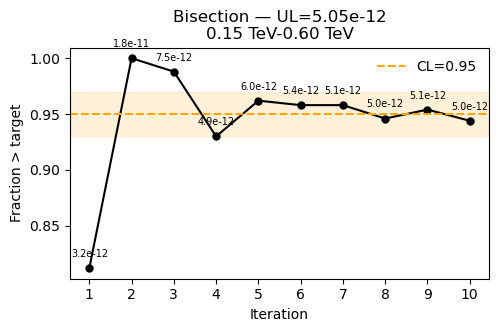

In [33]:
if not USE_ITERATIVE_ULS:
    fig, ax = plt.subplots(1, 1, figsize=(5.4, 3))
    ax.plot(amplitudes, lambda_f_frac_bkg,  color="k", label="$\\Lambda>\\Lambda_{bkg}$")
    ax.plot(amplitudes, lambda_f_frac_real, color="r", label="$\\Lambda>\\Lambda_{real}$")
    ax.axvline(amplitude95_bkg,  color="k", ls="--")
    ax.axvline(amplitude95_real, color="r", ls="--")
    ax.axhline(confidence_level, ls=":", color="lightgray", zorder=-2, label=f"C.L. = {confidence_level}")
    ax.legend(frameon=False)
    ax.set_xlabel("$\\phi_0$ [cm${}^{-2}$s${}^{-1}$ TeV${}^{-1}$]")
    ax.set_ylabel("Fraction of events")
    ax.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
    ax.set_xlim(1e-13, 5e-11); ax.set_xscale("log")
    plt.show()
else:
    fig, ax = plt.subplots(1, 1, figsize=(5.4, 3))
    ax.plot(range(1, len(hist_frac)+1), hist_frac, "ko-", ms=5)
    ax.axhline(confidence_level, color="orange", ls="--", lw=1.5, label=f"CL={confidence_level}")
    ax.axhspan(confidence_level-0.02, confidence_level+0.02, alpha=0.15, color="orange")
    for k, (a, f) in enumerate(zip(hist_amp, hist_frac)):
        ax.annotate(f"{a:.1e}", (k+1, f), textcoords="offset points", xytext=(0, 8), fontsize=7, ha="center")
    ax.set_xlabel("Iteration"); ax.set_ylabel("Fraction > target")
    ax.set_xticks(range(1, len(hist_frac)+1))
    ax.set_title(f"Bisection — UL={amp_ul:.2e}\n{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
    ax.legend(frameon=False)
    plt.show()

# Summary of results:

In [34]:
def _pwl_fluxes(amplitude, energy_edges):
    pwl = PowerLawSpectralModel(amplitude=amplitude * u.Unit("TeV-1 s-1 cm-2"), index=2)
    return pwl.integral(*energy_edges), pwl.energy_flux(*energy_edges).to(u.erg/(u.s*u.cm**2))

if not USE_ITERATIVE_ULS:
    flux_bkg,  flux_diff_bkg  = _pwl_fluxes(amplitude95_bkg,  energy_edges)
    flux_real, flux_diff_real = _pwl_fluxes(amplitude95_real, energy_edges)
else:
    flux_bkg  = flux_real      = flux_ul
    flux_diff_bkg = flux_diff_real = flux_diff_ul
    amplitude95_bkg = amplitude95_real = amp_ul

col_sens, col_ul, final_f_ul = ("33", "32", flux_real) if significance >= 0.0 else ("32", "31", flux_bkg)
print(f"Analysis of {type_obs} data in Energies {energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
print(f"\nSignificance of observations: {significance:.2f}σ\n")
print(f"\033[{col_sens}mSensitivity:  phi0={amplitude95_bkg:.2e}  Flux={flux_bkg:.2e}  dFlux={flux_diff_bkg:.2e}\033[0m")
print(f"\033[{col_ul}mUpper Limit:  phi0={amplitude95_real:.2e}  Flux={flux_real:.2e}  dFlux={flux_diff_real:.2e}\033[0m")

flux_ul_95_max = np.nanmax(flux_uls_95)
print(f"\nUL vs sky-map 95% max: {final_f_ul.value:.3e} vs {flux_ul_95_max:.3e}  "
      f"({(final_f_ul.value - flux_ul_95_max)/flux_ul_95_max*100:+.1f}%)")

Analysis of mono data in Energies 0.15 TeV-0.60 TeV

Significance of observations: -0.52σ

Sensitivity:  phi0=5.05e-12  Flux=2.53e-11 1 / (s cm2)  dFlux=1.12e-11 erg / (s cm2)
Upper Limit:  phi0=5.05e-12  Flux=2.53e-11 1 / (s cm2)  dFlux=1.12e-11 erg / (s cm2)

UL vs sky-map 95% max: 2.527e-11 vs 2.620e-11  (-3.6%)


### Showing the threshold simulated case

NameError: name 'idx_f_bkg' is not defined

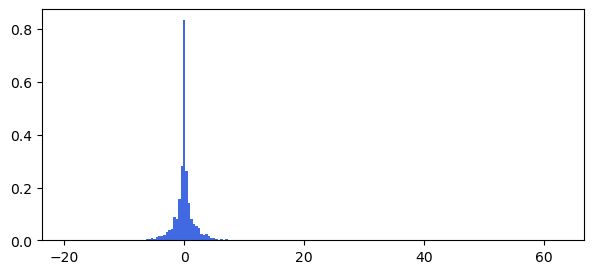

In [35]:
fig, axt = plt.subplots(1, 1, figsize=(7, 3))

axt.hist(lambda_bkg, lambda_bins, color="royalblue", 
         density=True, histtype="stepfilled", label=f"BKG sim\nN={len(lambda_bkg)}")
axt.hist(lambda_f[idx_f_bkg if significance < 0 else idx_f_real], 
         lambda_bins_ext, color="r", density=True, histtype="step", label=f"Sim of final UL")

axt.text(
    0.85, 0.87, f"p-value={p_value:.2f}\nsignificance={significance:.2f} $\\sigma$",
    ha="center", va="center", transform=axt.transAxes
)
axt.axvline(lambda_real, color="k", ls="--", label=f"Real data\n$\\Lambda=${lambda_real:.2f}")
axt.axvline(lambda_bkg_m, color="darkblue", ls=":", label=f"BKG median\n$\\Lambda=${lambda_bkg_m:.2f}")

axt.legend(frameon=False, loc=4)
axt.set_xlabel("$\\Lambda$"); axt.set_ylabel("Normalized counts")

pwl_sim = PowerLawSpectralModel(
    amplitude=amplitudes[idx_f_bkg if significance < 0 else idx_f_real] * u.Unit("TeV-1 s-1 cm-2"), index=2
)
flux_sim = pwl_sim.integral(*energy_edges)

axt.set_title(f"Sim flux {flux_sim:.2e},   {energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
fig.tight_layout()

plt.show()

### Showing the ULs in front of the real distributions

In [ ]:
fig, ax = plt.subplots(figsize=(3, 2))

mask = ~np.isnan(flux_uls_95)
single_pixel = np.sum(mask) == 1

h = ax.hist(flux_uls, 40, histtype="stepfilled", color="lightgray", label="Total distribution")

if single_pixel:
    ax.axvline(flux_uls_95[mask][0], color="k", lw=1, label="ULs in 95%")
else:
    ax.hist(flux_uls_95, h[1], histtype="step", color="k", label="ULs in 95%")

if significance >= 0.0:
    col_sens, col_ul = "0.5", "green"
    lab_sens, lab_ul = "Sensitivity", "Data UL"
    ls_sens,  ls_ul  = "--", "-"
else:
    col_sens, col_ul = "green", "0.5"
    lab_sens, lab_ul = "Data UL", "Overestimated UL"
    ls_sens,  ls_ul  = "-", "--"

ymid = np.diff(ax.get_ylim())[0] / 2
for val, ls, col, lab in [(flux_bkg.value, ls_sens, col_sens, lab_sens),
                          (flux_real.value, ls_ul,  col_ul,  lab_ul)]:
    ax.axvline(val, ls=ls, color=col)
    ax.errorbar(val, ymid, yerr=0, xerr=val*0.2, xuplims=True, ls="", color=col, label=lab)

ax.set_xlabel("Flux UL [1 / (s cm2)]"); ax.set_ylabel("Normalized counts")
ax.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
ax.legend(frameon=False, loc=(1.03, 0))
plt.show()

### Showing UL distributions in the simulations

In [ ]:
if compute_uls:
    
    fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.hist(ulmax_bkg, 25, density=True, 
            histtype="stepfilled", color="royalblue", label="Maximum UL in 95%", zorder=-5)
    
#     ax.hist(flux_uls, 50, density=True, histtype="step", ls=":", color="k", label="Real Data", zorder=10)
    ax.hist(flux_uls_95, 40, density=True, histtype="step", color="k", label="Real Data 95%", zorder=10)
    
    for data in ul_dist:
        data_95 = np.where(mask_threshold_95, data, np.nan).ravel()
        ax.hist(data_95, 40, density=True, histtype="step", color="0.5", alpha=0.2, zorder=0)
    
    flux_ul = flux_bkg if significance < 0 else flux_real
    ax.axvline(flux_ul.value, ls="-", color="crimson")
    ax.errorbar(flux_ul.value, np.diff(ax.get_ylim())[0]/2, yerr=0, 
        xerr=flux_ul.value*0.4, xuplims=True, ls="", color="crimson", label="Global UL")
    ax.plot([], [], color="gray", ls="-", marker="", 
            label="Simulation\ndistributions 95%")

    
    ax.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
    
    ax.legend(loc=(1.03, 0), frameon=False)
    ax.set_xlabel("Flux UL [1 / (s cm2)]"); ax.set_ylabel("Normalized counts")
    
    plt.show()

In [ ]:
if compute_uls:
    
    fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.hist(lambda_bkg, 30, density=True, 
            histtype="stepfilled", color="r", label="$\\Lambda$ (max TS')", zorder=-5)
    ts2_masked = np.where(mask_threshold_95, ts2, np.nan).ravel()
    ax.hist(ts2_masked, 30, density=True, histtype="step", color="k", label="Real Data", zorder=10)
    for data in ts2_dist:
        data = np.where(mask_threshold_95, data, np.nan).ravel()
        ax.hist(data, 30, density=True, histtype="step", color="0.5", alpha=0.2, zorder=0)
    
    ax.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
    ax.plot([], [], color="0.8", label="Simulated data")
    
    plt.legend(loc=(1.03, 0), frameon=False)
    ax.set_xlabel("TS'"); ax.set_ylabel("Normalized counts")
    ax.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
    plt.show()